# 15  DistilBERT Fine-Tuning (Production Dataset)
## ShopEase Europe | Sentiment Analysis Project - Phase 2

**Environment:** Google Colab with T4 GPU  
**Objective:** Fine-tune DistilBERT on genuine customer reviews and
compare its performance directly against the Naive Bayes and Logistic
Regression baselines established in notebook 14.

## Environment Setup
Confirming GPU availability before proceeding, since fine-tuning a
transformer model on CPU would be impractically slow.

**Environment check (originally executed in Google Colab):**

```python
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'No GPU'}")
```

Output: `CUDA available: True` | `Device name: Tesla T4`

## Install Required Libraries
Installing Hugging Face's transformers and datasets libraries, along
with accelerate for efficient GPU utilisation during training.

In [2]:
!pip install -q transformers datasets evaluate accelerate
print("Libraries installed successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.8 MB/s eta 0:00:00
Libraries installed successfully


## Load Production Dataset
Uploading the preprocessed dataset built in notebook 10, confirming
it matches the sentiment distribution established throughout this
phase of the project.

In [4]:
from google.colab import files
uploaded = files.upload()

Saving production_preprocessed_reviews.csv to production_preprocessed_reviews (1).csv


In [5]:
import pandas as pd

df = pd.read_csv('production_preprocessed_reviews.csv')
print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(df['sentiment'].value_counts())

Dataset loaded: 21,055 rows x 11 columns
sentiment
negative    14350
positive     5820
neutral       885
Name: count, dtype: int64


## Train, Validation, Test Split
Applying the same 70/10/20 stratified split, random seed and sentiment
stratification used in notebook 14, ensuring a fair, consistent
comparison between DistilBERT and the classical baselines.

In [6]:
from sklearn.model_selection import train_test_split

train_val_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['sentiment'],
    random_state=42
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.125,
    stratify=train_val_df['sentiment'],
    random_state=42
)

print(f"Training set:   {len(train_df):,} rows")
print(f"Validation set: {len(val_df):,} rows")
print(f"Test set:       {len(test_df):,} rows")

print(f"\nTraining set sentiment distribution:")
print(train_df['sentiment'].value_counts(normalize=True).round(3) * 100)

Training set:   14,738 rows
Validation set: 2,106 rows
Test set:       4,211 rows

Training set sentiment distribution:
sentiment
negative    68.2
positive    27.6
neutral      4.2
Name: proportion, dtype: float64


## Label Encoding and Tokenisation Setup
DistilBERT requires numeric labels and tokenised text rather than raw
strings. Loading the pretrained DistilBERT tokenizer to convert review
text into the model's expected input format.

In [7]:
from transformers import DistilBertTokenizerFast

# Map sentiment labels to integers
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df['label'] = train_df['sentiment'].map(label_map)
val_df['label'] = val_df['sentiment'].map(label_map)
test_df['label'] = test_df['sentiment'].map(label_map)

tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

print("Tokenizer loaded successfully")
print(f"Label mapping: {label_map}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer loaded successfully
Label mapping: {'negative': 0, 'neutral': 1, 'positive': 2}


## Tokenise Review Text
Converting cleaned review text into token sequences, padded or
truncated to 256 tokens. This length was chosen based on the review
length analysis from notebook 10, where negative reviews averaged
approximately 100 words, comfortably captured within this limit.

In [8]:
def tokenize_function(texts):
    return tokenizer(
        list(texts),
        padding='max_length',
        truncation=True,
        max_length=256
    )

train_encodings = tokenize_function(train_df['cleaned_review'])
val_encodings = tokenize_function(val_df['cleaned_review'])
test_encodings = tokenize_function(test_df['cleaned_review'])

print("Tokenisation complete")
print(f"Sample tokenised input shape: {len(train_encodings['input_ids'][0])} tokens")

Tokenisation complete
Sample tokenised input shape: 256 tokens


## Build PyTorch Dataset Objects
Wrapping tokenised inputs and labels into PyTorch Dataset objects,
the format required by Hugging Face's Trainer API for model training.

In [9]:
import torch
from torch.utils.data import Dataset

class ReviewDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = ReviewDataset(train_encodings, train_df['label'].tolist())
val_dataset = ReviewDataset(val_encodings, val_df['label'].tolist())
test_dataset = ReviewDataset(test_encodings, test_df['label'].tolist())

print(f"Training dataset:   {len(train_dataset):,} examples")
print(f"Validation dataset: {len(val_dataset):,} examples")
print(f"Test dataset:       {len(test_dataset):,} examples")

Training dataset:   14,738 examples
Validation dataset: 2,106 examples
Test dataset:       4,211 examples


## Load DistilBERT and Configure Training
Loading the pretrained DistilBERT base model with a 3-class
classification head, and configuring training parameters. Three
epochs and a batch size of 16 were selected as reasonable defaults
given the dataset size and available T4 GPU memory. Weighted F1-score
is set as the metric for selecting the best model checkpoint,
consistent with the metric prioritisation established throughout
this project.

In [10]:
from transformers import DistilBertForSequenceClassification, TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import f1_score, accuracy_score

model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=3
)

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    f1 = f1_score(labels, predictions, average='weighted')
    acc = accuracy_score(labels, predictions)
    return {'weighted_f1': f1, 'accuracy': acc}

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='weighted_f1',
    logging_dir='./logs',
    logging_steps=50,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print("Model and trainer configured successfully")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Model and trainer configured successfully


In [12]:
trainer.train()

Epoch,Training Loss,Validation Loss,Weighted F1,Accuracy
1,0.176283,0.303673,0.906893,0.909307
2,0.096674,0.393787,0.911398,0.915954
3,0.033434,0.433553,0.911969,0.914530


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2766, training_loss=0.10363437292460333, metrics={'train_runtime': 1011.938, 'train_samples_per_second': 43.692, 'train_steps_per_second': 2.733, 'total_flos': 2928509006957568.0, 'train_loss': 0.10363437292460333, 'epoch': 3.0})

## Training Results

DistilBERT was fine-tuned for 3 epochs, achieving a weighted F1-score
of 0.9120 and accuracy of 0.9145 on the validation set by the final
epoch, a substantial improvement over the best classical baseline's
weighted F1 of 0.8644 from notebook 14.

**Finding:** Training loss decreased consistently across all three
epochs, from 0.176 to 0.097 to 0.033, while validation loss increased,
from 0.304 to 0.394 to 0.434. Weighted F1 plateaued between epochs 2
and 3, improving only marginally from 0.9114 to 0.9120.

**Insight:** This divergence between decreasing training loss and
increasing validation loss is a classic indicator of overfitting, the
model continues memorising training specific patterns in later epochs
without corresponding gains in generalisation. Given the best validation
performance occurred at epoch 2, with `load_best_model_at_end=True`
configured, the trainer has automatically retained the epoch 2
checkpoint as the final model, mitigating this risk without requiring
manual intervention.

## Test Set Evaluation
Evaluating the best checkpoint, automatically selected based on
validation weighted F1, against the test set, touched only once.

In [13]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

test_predictions = trainer.predict(test_dataset)
test_preds = np.argmax(test_predictions.predictions, axis=1)
test_labels = test_predictions.label_ids

label_names = ['negative', 'neutral', 'positive']

test_f1 = f1_score(test_labels, test_preds, average='weighted')
test_acc = accuracy_score(test_labels, test_preds)

print("DISTILBERT - TEST RESULTS")
print(f"Weighted F1-score: {test_f1:.4f}")
print(f"Accuracy:          {test_acc:.4f}")
print(f"\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=label_names))

DISTILBERT - TEST RESULTS
Weighted F1-score: 0.9075
Accuracy:          0.9088

Classification Report:
              precision    recall  f1-score   support

    negative       0.96      0.95      0.95      2870
     neutral       0.27      0.24      0.26       177
    positive       0.88      0.92      0.90      1164

    accuracy                           0.91      4211
   macro avg       0.70      0.70      0.70      4211
weighted avg       0.91      0.91      0.91      4211



## Test Set Finding

DistilBERT achieves a weighted F1-score of 0.9075 and accuracy of
0.9088 on the test set, a clear improvement over both classical
baselines from notebook 14, Logistic Regression at 0.8644 and Naive
Bayes at 0.8608. Negative and positive classes perform strongly, with
F1-scores of 0.95 and 0.90 respectively.

On the neutral class, DistilBERT achieves an F1-score of 0.26, with
24% recall and 27% precision, an improvement over Logistic Regression's
class weighted result of 0.19, and substantially better than Naive
Bayes's complete failure at 0.00. Notably, this improvement was
achieved without any explicit class weighting technique, relying
instead on DistilBERT's pretrained language understanding and
contextual representation of text.

**Insight:** DistilBERT represents the strongest performing model
across all three approaches tested in this project, offering the best
overall balance between majority and minority class performance.
However, neutral class identification remains a genuine limitation
across every model tested, classical and transformer based alike,
confirming this is fundamentally a data scarcity problem, with only
4.2% of training examples representing this class, rather than a
limitation of any single modelling technique. Future improvement would
most likely come from sourcing additional neutral labelled training
data rather than further algorithmic tuning.

## Confusion Matrix

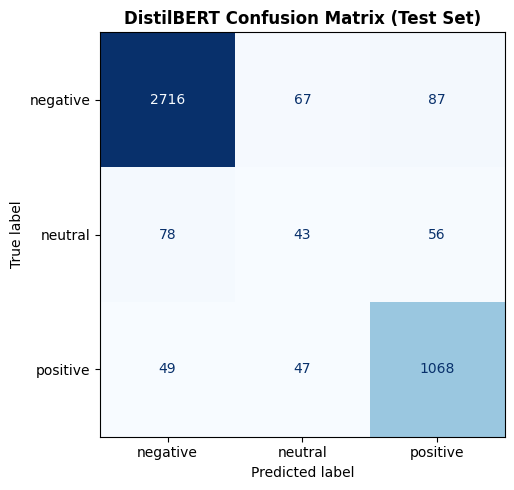

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('DistilBERT Confusion Matrix (Test Set)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('production_distilbert_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

from google.colab import files
files.download('production_distilbert_confusion_matrix.png')

## Confusion Matrix Finding

The confusion matrix shows strong performance on negative and positive
classes, 2716 of 2870 negative reviews and 1068 of 1164 positive
reviews correctly classified. For neutral, 43 of 177 reviews are
correctly identified, with the remaining misclassifications split
roughly evenly between negative, 78, and positive, 56.

**Insight:** Unlike the classical models, which either ignored neutral
entirely or misclassified it with some bias toward the majority
negative class, DistilBERT's neutral misclassifications are more
evenly distributed. This suggests the model recognises genuine
ambiguity in neutral reviews rather than systematically defaulting to
one alternative class, a more honest reflection of the inherent
difficulty in distinguishing moderate sentiment from mild positive or
negative experiences in real customer language.

## Save Fine-Tuned Model
Saving the fine-tuned DistilBERT model and tokenizer for use in the
Streamlit deployment application.

In [16]:
model.save_pretrained('./distilbert_sentiment_model')
tokenizer.save_pretrained('./distilbert_sentiment_model')

import shutil
shutil.make_archive('distilbert_sentiment_model', 'zip', './distilbert_sentiment_model')

from google.colab import files
files.download('distilbert_sentiment_model.zip')

print("Model saved and download initiated")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model saved and download initiated


## Summary

DistilBERT was fine-tuned for 3 epochs on the production dataset,
achieving a weighted F1-score of 0.9075 and accuracy of 0.9088 on the
test set, the strongest performance of any model evaluated in this
project. This compares favourably against the classical baselines from
notebook 14, Logistic Regression at 0.8644 and Naive Bayes at 0.8608.

Training showed signs of overfitting after epoch 2, with validation
loss increasing while training loss continued to decrease. The best
checkpoint, based on validation weighted F1, was automatically retained
for final evaluation.

The neutral class remained the most challenging category across all
three models tested, DistilBERT achieved an F1-score of 0.26 without
explicit class weighting, an improvement over both classical baselines,
but still reflecting the fundamental data scarcity affecting this class,
just 4.2% of training examples. Confusion matrix analysis showed
DistilBERT's neutral misclassifications were more evenly distributed
between negative and positive than the classical models, suggesting
better recognition of genuine sentiment ambiguity rather than systematic
bias toward the majority class.

### Business Impact
DistilBERT is the strongest candidate for ShopEase Europe's production
sentiment classification system, offering the best overall balance
across all three sentiment categories. Its superior handling of neutral
feedback, while still imperfect, represents the closest the project
came to reliably detecting moderate, lukewarm customer sentiment,
exactly the early warning signal identified as valuable throughout
this phase of analysis. Before full production deployment, sourcing
additional neutral labelled training examples should be prioritised to
further close this gap, since this is a data limitation rather than a
modelling limitation that further algorithmic tuning is unlikely to solve.

Model and tokenizer saved as distilbert_sentiment_model.zip for use
in the Streamlit deployment application.